# 01 · Introduction

QProgram is a Python library for writing pulse programs. These programs specify the signals, timing, and measurements used to control quantum hardware. This notebook introduces the QProgram syntax: you will create a program, add operations, define buses and waveforms, save and load programs, and run an example on the reference platform.

The tutorial has three notebooks. **Introduction** covers the main language features. **Basics** introduces variables, loops, and measurement results. **Advanced** covers language extensions and platform definitions.

The examples use QProgram's Python reference platform and run locally without connected instruments, hardware drivers, or a cloud account.

## Before you start

Run the next two cells to set up the notebook. The first installs QProgram if it is missing, which may be necessary in a fresh Google Colab session. The second displays the installed Python and QProgram versions. QProgram requires Python 3.11 or later; versions 3.11 through 3.14 are tested.

In [1]:
# Install QProgram if it is not already available in this Python environment.
try:
    import qprogram
except ImportError:
    import subprocess
    import sys

    subprocess.run([sys.executable, "-m", "pip", "install", "qprogram[viz]==0.2.0"], check=True)
    import qprogram

In [2]:
from importlib.metadata import version
from platform import python_version

print("Python:", python_version())
print("QProgram:", version("qprogram"))

Python: 3.13.12
QProgram: 0.2.0


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import qprogram as qp
from qprogram import MeasurementField
from qprogram.buses import BusNaming, BusSchema
from qprogram.waveforms import (
    Arbitrary,
    FlatTop,
    Gaussian,
    IQDrag,
    IQPair,
    IQZero,
    Ramp,
    Square,
    SuddenNetZero,
)

## 1.1 Creating a program

Create a `qp.QProgram` object, then call its methods to add operations. Each operation is stored as a node in the program's tree structure. Building a program does not execute it, so you can inspect, modify, and save it before running it.

Operations target a bus, which identifies a signal path such as a qubit's drive or readout line. For now, we will identify buses with strings such as `"q0/drive"`. Section 1.3 introduces schemas, which add metadata and validation to bus references.

The optional `label` and `description` arguments provide a name and a description for the program. Both are included when you save it.

The example below sets the drive frequency to 4.85 GHz and adds a 40 ns pulse.

In [4]:
qprogram = qp.QProgram(label="first_program", description="One drive pulse on qubit 0.")
qprogram.set_frequency("q0/drive", 4.85e9)
qprogram.play("q0/drive", IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15))

print(qp.dumps(qprogram))

#!QProgram 0.2

metadata:
  label: "first_program"
  description: "One drive pulse on qubit 0."

body:
  set_frequency "q0/drive" 4850000000.0
  play "q0/drive" IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)



`qp.dumps(qprogram)` returns the program as text in the `.qp` format. The header contains its label and description, followed by the operations in the order they were added. Section 1.6 shows how to save this text to a file.

You can also inspect the program directly. `buses` returns the bus names currently used anywhere in the program, and `body.elements` is the list of nodes directly inside its main body.

In [5]:
print("buses:", qprogram.buses)

# The two calls above added a SetFrequency node and a Play node, in that order.
print(type(qprogram.body.elements[0]))
print(type(qprogram.body.elements[1]))

buses: {'q0/drive'}
<class 'qprogram.operations.set_frequency.SetFrequency'>
<class 'qprogram.operations.play.Play'>


## 1.2 Operations

Use the methods below to add operations to the program. Each call adds one node and returns `None`, except for `measure` and `get_parameter`, which return objects used to access their results.

Durations are expressed in nanoseconds, frequencies in hertz, and phases in radians. Gain and offset are dimensionless. Numeric arguments can also use variables and expressions, which are introduced in **Basics**.

| Method | Node added | Purpose |
|---|---|---|
| `play(bus, waveform)` | `Play` | Play a waveform on a bus. |
| `measure(bus, waveform, weights, *, name=None, fields=(MeasurementField.IQ,))` | `Measure` | Play a readout waveform and acquire a measurement. Returns a `MeasurementHandle`. |
| `wait(bus, duration)` | `Wait` | Wait for the specified duration on one bus. |
| `sync(buses=None)` | `Sync` | Align the selected buses at the latest of their current times. |
| `set_frequency(bus, frequency)` | `SetFrequency` | Set the carrier frequency of a bus. |
| `set_phase(bus, phase)`, `reset_phase(bus)` | `SetPhase`, `ResetPhase` | Set the oscillator phase or reset it to zero. |
| `set_gain(bus, gain)` | `SetGain` | Set the gain applied to the bus output. |
| `set_offset(bus, offset_path0, offset_path1=None)` | `SetOffset` | Set a DC offset for one or both signal paths. |
| `set_parameter(bus, parameter, value)` | `SetParameter` | Set a platform configuration parameter. |
| `get_parameter(bus, parameter)` | `GetParameter` | Read a platform configuration parameter. Returns a `Variable` populated during execution. |
| `call(fragment, *args, **kwargs)` | `Call` | Call a reusable program fragment, covered in **Advanced**. |

These operations provide a common interface for functions supported by control instruments. **Advanced** shows how vendor namespaces can expose additional operations.

Use `average(shots)` to repeat operations for averaging and `sweep(variable, source)` to iterate over values. **Basics** covers loops and how to combine them with `|`. Conditional blocks using `if_`, `elif_`, and `else_` are covered in **Advanced**.

### Building a pulse sequence

The example below plays a drive pulse, waits for 400 ns, and then performs a readout. The readout waveform uses `IQZero`, which places the supplied waveform on the in-phase (I) path and sets the quadrature (Q) path to zero. The `fields` argument selects the measurement outputs to return.

`set_gain` controls the gain applied to the bus output, while a waveform's `amplitude` controls the amplitude of that waveform. `reset_phase` resets the oscillator phase to zero, providing a consistent phase reference.

`play`, `measure`, and `wait` advance the time on their target bus.

In [6]:
READOUT_NS = 2000  # Use the same duration for the readout pulse and integration weights.

readout_pulse = IQZero(Square(amplitude=0.2, duration=READOUT_NS))  # I envelope with Q set to zero.
weights = IQPair(
    I=Square(amplitude=1.0, duration=READOUT_NS),
    Q=Square(amplitude=1.0, duration=READOUT_NS),
)
pi_pulse = IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)

qprogram = qp.QProgram(label="prepare_and_read", description="A pi pulse on qubit 0, then a readout.")
qprogram.set_frequency("q0/drive", 4.85e9)
qprogram.set_gain("q0/drive", 1.0)
qprogram.reset_phase("q0/drive")
qprogram.play("q0/drive", pi_pulse)
qprogram.wait("q0/drive", 400)  # Wait 400 ns before synchronising with the readout bus.
qprogram.set_frequency("q0/readout", 7.20e9)
qprogram.sync(["q0/drive", "q0/readout"])
m0 = qprogram.measure(
    "q0/readout", readout_pulse, weights, fields=(MeasurementField.IQ, MeasurementField.STATE)
)

print(qp.dumps(qprogram))

#!QProgram 0.2

metadata:
  label: "prepare_and_read"
  description: "A pi pulse on qubit 0, then a readout."

body:
  set_frequency "q0/drive" 4850000000.0
  set_gain "q0/drive" 1.0
  reset_phase "q0/drive"
  play "q0/drive" IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
  wait "q0/drive" 400
  set_frequency "q0/readout" 7200000000.0
  sync "q0/drive" "q0/readout"
  measure "q0/readout" IQZero(envelope=Square(amplitude=0.2, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="m0" fields=["state", "iq"]



### Synchronising buses

Each bus has its own timeline. A pulse, measurement, or wait advances the time on the bus it targets. Operations on different buses therefore do not automatically run one after another, even if their calls appear on consecutive lines of Python.

Use `sync(buses)` when an operation must wait for work on other buses to finish. It advances each selected bus to the latest current time among them. In `qprogram`, this makes the readout wait until the drive pulse and the 400 ns delay have finished.

Calling `sync()` without an argument synchronises every bus in the program. An empty list, `sync([])`, raises `qp.ValidationError`. Specify the buses explicitly when only those buses need to be synchronised; **Advanced** shows how this choice affects program transformations.

In [7]:
# The earlier qprogram.sync(["q0/drive", "q0/readout"]) appears in .qp as:
# sync "q0/drive" "q0/readout"

qprogram = qp.QProgram(label="broadcast_sync")
qprogram.sync()  # Synchronise all buses in the program.

# Inspect the sync instruction below: no individual buses are listed.
print(qp.dumps(qprogram))

#!QProgram 0.2

metadata:
  label: "broadcast_sync"

body:
  sync



In [8]:
# An empty list is invalid; omit the argument to synchronise all buses.
try:
    qprogram.sync([])
except qp.ValidationError as exc:
    print(exc)

sync([]) is ambiguous; pass None (or no argument) to sync all buses


### Selecting measurement outputs

`measure(bus, waveform, weights)` plays the readout waveform and acquires the response. You do not need a separate `play` call for that readout pulse. The `weights` waveform defines the integration weights applied to the acquired signal. These examples use constant weights of 1.0 for both quadratures.

Use `fields` to request one or more outputs:

- `MeasurementField.IQ`: the integrated I and Q values, returned by default.
- `MeasurementField.STATE`: the state classified by the platform as 0 or 1.
- `MeasurementField.RAW`: the raw ADC trace.

An invalid field raises a validation error when you call `measure`.

The call returns a `MeasurementHandle`, which identifies the measurement by name. Keep this handle to retrieve the corresponding data after execution, as shown in section 1.7. You can choose a name with `name=`; otherwise, QProgram generates one. Names must be unique within the program, and handles with the same name compare equal.

In [9]:
print("measurement name:", m0.name)

# "bogus" is not a supported measurement field.
try:
    qprogram.measure("q0/readout", readout_pulse, weights, fields=("iq", "bogus"))
except qp.ValidationError as exc:
    print(exc)

measurement name: m0
unknown measurement field(s) ['bogus']. Known fields: ['iq', 'raw', 'state']. A vendor extension adds its own by registering `measure.fields.<name>` via qprogram.protocol.register_capability_tokens.


### Setting bus properties

Methods such as `set_frequency` and `set_gain` describe settings that a platform can change within a pulse sequence. Use `set_parameter(bus, name, value)` for platform configuration, such as an external attenuator setting. Changing these settings may require host communication between runs, so sweeping them can involve additional work for each point.

Parameter names are defined by the platform and are not validated by QProgram's core. Use the platform's `get_parameters(bus)` method to find the available parameters.

`get_parameter(bus, name)` adds a read operation and returns a `Variable` that receives the value during execution. In the output below, the `var` declaration belongs to the variable returned by `get_parameter`. Its identifier is derived from the bus and parameter names. **Basics** explains how to work with variables.

`set_offset` sets the DC level of a signal path, while `set_gain` scales the waveforms played on that bus. Neither specifies a duration. Use `play` when you want to add a waveform with a defined duration to the bus timeline.

In [10]:
qprogram = qp.QProgram(label="settings")
qprogram.set_parameter("q0/drive", "attenuation", 20.0)
q0_drive_attenuation = qprogram.get_parameter("q0/drive", "attenuation")
qprogram.set_offset("q0/flux", 0.05)

# The output includes the variable declaration created by get_parameter.
print(qp.dumps(qprogram))

#!QProgram 0.2

metadata:
  label: "settings"

body:
  var q0_drive_attenuation label="q0/drive.attenuation"

  set_parameter "q0/drive" "attenuation" 20.0
  get_parameter "q0/drive" "attenuation" -> q0_drive_attenuation
  set_offset "q0/flux" 0.05



## 1.3 Buses and schemas

Plain string bus names do not provide validation. For example, QProgram will accept `"q0/raedout"` while building a program, even if you intended `"q0/readout"`.

A `BusSchema` defines the bus types available for each kind of device element. It provides structured references such as `q[0].drive`, so you can select a bus through attributes. A schema describes element types without specifying how many elements exist, so it accepts any index.

Each reference is a `BusRef`, a subclass of `str` that also carries bus metadata. You can use it wherever a QProgram method accepts a bus name. Two attributes determine the main validation checks:

- `channel` specifies whether the bus accepts an `IQ` waveform or a `single` waveform. In the schema below, drive and readout buses use IQ waveforms, while flux buses use single-channel waveforms.
- `acquires` indicates whether the bus supports acquisition. A `measure` operation requires this capability.

QProgram uses this metadata to validate operations as you add them.

In [11]:
schema = BusSchema.flux_tunable_transmon()
q = schema.q

# Drive and readout buses accept IQ waveforms; only readout supports acquisition.
print("drive channel:", q[0].drive.channel)
print("drive acquires:", q[0].drive.acquires)
print("readout channel:", q[0].readout.channel)
print("readout acquires:", q[0].readout.acquires)

# The flux bus accepts a single-channel waveform and does not support acquisition.
print("flux channel:", q[0].flux.channel)
print("flux acquires:", q[0].flux.acquires)

print("BusRef is a string:", isinstance(q[0].drive, str))
print(q[7].drive)  # The schema accepts any index; it does not define the device size.

drive channel: IQ
drive acquires: False
readout channel: IQ
readout acquires: True
flux channel: single
flux acquires: False
BusRef is a string: True
q7/drive


QProgram includes schemas for transmons, flux-tunable transmons, and fluxonium qubits. Each also has a `_coupled` variant that adds a `c` element for tunable couplers.

`BusSchema.transmon()` provides drive and readout buses. `BusSchema.flux_tunable_transmon()` also provides a flux bus. To define a custom schema, start with `BusSchema()` and register element types with `add_element`.

In [12]:
# Printing a schema shows its element types and bus definitions.
print(BusSchema.transmon())
print(BusSchema.flux_tunable_transmon())
print(BusSchema.fluxonium())
print(BusSchema.flux_tunable_transmon_coupled())  # Adds the coupler element c.

BusSchema(q(drive: ('IQ', False), readout: ('IQ', True)))
BusSchema(q(drive: ('IQ', False), readout: ('IQ', True), flux: ('single', False)))
BusSchema(q(drive: ('IQ', False), readout: ('IQ', True), flux_x: ('single', False), flux_z: ('single', False)))
BusSchema(q(drive: ('IQ', False), readout: ('IQ', True), flux: ('single', False)), c(flux: ('single', False)))


### Validating operations with a schema

A schema allows QProgram to check three requirements when you add an operation:

1. The waveform must match the bus channel type. For a measurement, this applies to both the readout waveform and the integration weights.
2. A measurement bus must support acquisition.
3. Every `BusRef` must belong to the program's schema. A reference from a separate schema is rejected even if its bus name and properties match.

Each invalid operation below raises `qp.ValidationError`. Read the messages to see which requirement was violated.

In [13]:
qprogram = qp.QProgram(label="deliberate_mistakes", schema=schema)

# A drive bus requires an IQ waveform, but Square is single-channel.
try:
    qprogram.play(q[0].drive, Square(amplitude=0.5, duration=40))
except qp.ValidationError as exc:
    print(exc)

Bus 'q0/drive' is an IQ channel but received a single-channel Waveform (Square). Use an IQWaveform (e.g. IQPair, IQDrag) instead.


In [14]:
# A flux bus requires a single-channel waveform, but readout_pulse is IQ.
try:
    qprogram.play(q[0].flux, readout_pulse)
except qp.ValidationError as exc:
    print(exc)

Bus 'q0/flux' is a single channel but received an IQWaveform (IQZero). Use a single-channel Waveform (e.g. Square, FlatTop) instead.


In [15]:
# The waveform types match, but the drive bus does not support acquisition.
try:
    qprogram.measure(q[0].drive, readout_pulse, weights)
except qp.ValidationError as exc:
    print(exc)

Bus 'q0/drive' does not support acquisition (acquires=False). measure() can only be called on buses with an ADC (e.g. readout buses).


In [16]:
# This bus belongs to a different schema, even though its name is also q0/drive.
separate_schema = BusSchema.transmon()
try:
    qprogram.play(separate_schema.q[0].drive, pi_pulse)
except qp.ValidationError as exc:
    print(exc)

BusRef 'q0/drive' (element='q', kind='drive') comes from a different BusSchema than the one attached to this QProgram. A program may use only one schema; use a plain string bus name if you need to reference a bus that lives outside the schema.


You can use both `BusRef` objects and plain strings in the same program. Schema validation applies to the `BusRef` objects; a plain string does not provide the metadata needed for these checks.

The choice also affects automatically generated measurement names. With a `BusRef`, names are generated per bus, such as `q0/readout/m0`. With a plain string, names use a program-wide counter, such as `m0` in section 1.2.

`BusNaming` controls how structured references become bus names. Its pattern uses the placeholders `{element}`, `{index}`, and `{kind}`. In the example below, `rebind(schema=...)` returns a program using a different naming pattern. The resolved bus name changes, while the structural reference in the `.qp` body remains `q[0].drive`. The naming pattern is also stored when the program is saved.

In [17]:
qprogram = qp.QProgram(label="prepare_and_read", schema=schema)
qprogram.set_frequency(q[0].drive, 4.85e9)
qprogram.play(q[0].drive, pi_pulse)
qprogram.sync([q[0].drive, q[0].readout])
m_checked = qprogram.measure(
    q[0].readout, readout_pulse, weights, fields=(MeasurementField.IQ, MeasurementField.STATE)
)
prepare_and_read_text = qp.dumps(qprogram)

print("handle with a BusRef:", m_checked.name)  # Named per bus.
print("handle with a string:", m0.name)  # Named per program.

handle with a BusRef: q0/readout/m0
handle with a string: m0


In [18]:
other_rack = BusSchema.flux_tunable_transmon(naming=BusNaming("{kind}_{element}{index}"))
original_buses = qprogram.buses
qprogram = qprogram.rebind(schema=other_rack)

print("original bus names:", original_buses)
print("rebound bus names:", qprogram.buses)

# The naming pattern changes, but the body still refers to q[0].drive.
print(qp.dumps(qprogram))

original bus names: {'q0/drive', 'q0/readout'}
rebound bus names: {'drive_q0', 'readout_q0'}
#!QProgram 0.2

metadata:
  label: "prepare_and_read"

schema:
  naming: "{kind}_{element}{index}"
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  set_frequency q[0].drive 4850000000.0
  play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
  sync q[0].drive q[0].readout
  measure q[0].readout IQZero(envelope=Square(amplitude=0.2, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="readout_q0/m0" fields=["state", "iq"]



## 1.4 Waveforms

A waveform describes the envelope of a pulse. Waveform objects are independent of programs and hardware, so you can create, inspect, compare, and plot them on their own.

For a single-channel waveform, `envelope(resolution=1)` returns its samples as a NumPy array, and `get_duration()` returns its duration in nanoseconds. An IQ waveform provides `get_I()` and `get_Q()` to access its two component waveforms, along with `get_duration()`.

The waveform base class provides methods such as `area()`, `peak_amplitude()`, `rms_amplitude()`, `spectrum()`, and `plot()`. These methods are also available to custom waveforms that implement the interface described in **Advanced**.

In [19]:
drive_envelope = Gaussian(amplitude=0.5, duration=40, sigma=8)

print("duration:", drive_envelope.get_duration(), "ns")
print("samples:", drive_envelope.envelope())  # The default resolution is 1 ns.
print("peak:", drive_envelope.peak_amplitude())
print("area:", drive_envelope.area(), "amplitude × ns")

duration: 40 ns
samples: [0.02563363 0.03449381 0.04569688 0.05959996 0.07652787 0.09674029
 0.12039524 0.14751133 0.17793263 0.21130022 0.24703499 0.28433553
 0.32219436 0.35943378 0.39476078 0.42683818 0.45436688 0.4761724
 0.49128773 0.49902439 0.49902439 0.49128773 0.4761724  0.45436688
 0.42683818 0.39476078 0.35943378 0.32219436 0.28433553 0.24703499
 0.21130022 0.17793263 0.14751133 0.12039524 0.09674029 0.07652787
 0.05959996 0.04569688 0.03449381 0.02563363]
peak: 0.49902439055373776
area: 9.876928139128925 amplitude × ns


QProgram provides twelve single-channel waveform types:

- `Square`, `FlatTop`, and `Tukey` for constant or smoothly varying envelopes.
- `Gaussian`, `Sech`, and `GaussianDragCorrection` for shaped envelopes and a DRAG correction.
- `Sine` and `Cosine` for periodic envelopes.
- `Ramp` and `SuddenNetZero` for shapes commonly used in flux control.
- `Chained` for concatenating waveforms.
- `Arbitrary` for a waveform defined by an array of samples.

The five IQ waveform types combine or transform single-channel waveforms:

- `IQPair` takes separate I and Q waveforms.
- `IQZero` takes an I waveform and sets Q to zero.
- `IQDrag` constructs a drive envelope with a quadrature correction controlled by `beta`.
- `IQRotation` rotates an existing IQ pair in the IQ plane.
- `Modulated` modulates a real envelope onto a carrier.

Waveforms compare and hash by their structure and parameter values. Two separately created `Gaussian(0.5, 40, 8)` objects therefore compare equal. You can concatenate compatible shapes with `a + b`, which creates a `Chained` waveform.

A waveform is not tied to a particular bus. For example, you can play a `Square` directly on a flux bus or wrap it in `IQZero` to use it on an IQ bus.

In [20]:
# Trapezoidal integration gives 49.5 at the default 1 ns resolution.
print(Square(amplitude=0.5, duration=100).area())

# FlatTop adds its buffer outside the specified duration.
padded = FlatTop(amplitude=0.5, duration=200, smooth_duration=20, buffer=10)
print("duration including buffer:", padded.get_duration(), "ns")

# Waveforms with the same type and parameters compare equal.
same_envelope = Gaussian(amplitude=0.5, duration=40, sigma=8)
print(drive_envelope == same_envelope)

# Adding compatible waveforms joins them in time.
joined = Square(amplitude=0.2, duration=10) + Square(amplitude=0.1, duration=10)
print("concatenated duration:", joined.get_duration(), "ns")

49.5
duration including buffer: 220 ns
True
concatenated duration: 20 ns


### Using waveform aliases

You can pass a string alias to `play` or `measure` instead of supplying the waveform immediately. This lets you define the sequence first and supply its waveforms later.

Use `with_waveforms` to resolve aliases. It returns a new program and leaves the original unchanged. A dictionary maps each alias to a waveform. `body.waveforms()` returns the program's waveform references. In this example, all references start as string aliases. Aliases without a matching entry remain unresolved, and mapping entries that are not used by the program are ignored.

When a waveform is supplied, QProgram checks that it matches the bus channel type. The last example below deliberately binds a single-channel `Gaussian` to an IQ drive bus to demonstrate this validation.

For more flexible lookup, `qp.WaveformLibrary` can supply different waveforms for the same alias on different buses. It also has a text format for storing waveform definitions separately from the program.

In [21]:
qprogram = qp.QProgram(label="prepare_and_read", schema=schema)
qprogram.play(q[0].drive, "pi")
qprogram.sync([q[0].drive, q[0].readout])
qprogram.measure(q[0].readout, "readout", "weights", fields=(MeasurementField.IQ, MeasurementField.STATE))

print(qprogram.body.waveforms())  # The three aliases: "pi", "readout", and "weights".
print(qp.dumps(qprogram))  # The play and measure operations refer to those aliases.

{'readout', 'weights', 'pi'}
#!QProgram 0.2

metadata:
  label: "prepare_and_read"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  play q[0].drive "pi"
  sync q[0].drive q[0].readout
  measure q[0].readout "readout" "weights" name="q0/readout/m0" fields=["state", "iq"]



In [22]:
# Supply a waveform for each alias to create a new, resolved program.
qprogram_with_resolved_waveforms = qprogram.with_waveforms({
    "pi": pi_pulse,
    "readout": readout_pulse,
    "weights": weights,
})
print(qp.dumps(qprogram_with_resolved_waveforms))  # The output now contains the waveform definitions.
print(qprogram.body.waveforms())  # The original program still contains the aliases.

#!QProgram 0.2

metadata:
  label: "prepare_and_read"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires
    flux info=single

body:
  play q[0].drive IQDrag(amplitude=0.62, duration=40, sigma=10, beta=0.15)
  sync q[0].drive q[0].readout
  measure q[0].readout IQZero(envelope=Square(amplitude=0.2, duration=2000)) IQPair(I=Square(amplitude=1.0, duration=2000), Q=Square(amplitude=1.0, duration=2000)) name="q0/readout/m0" fields=["state", "iq"]

{'readout', 'weights', 'pi'}


In [23]:
# "pi" is used on an IQ bus, so a single-channel Gaussian is not a valid replacement.
try:
    qprogram.with_waveforms({"pi": Gaussian(amplitude=0.62, duration=40, sigma=10)})
except qp.ValidationError as exc:
    print(exc)

Bus 'q0/drive' is an IQ channel but received a single-channel Waveform (Gaussian). Use an IQWaveform (e.g. IQPair, IQDrag) instead.


## 1.5 Plotting

QProgram provides built-in plotting methods for waveforms. `waveform.plot()` creates a plot and returns the Matplotlib `Axes`, which you can use to add a title, reference lines, or annotations. Measurement results provide a similar plotting interface, shown in section 1.7.

For a quick preview, place a waveform object on the last line of a notebook cell. Its HTML representation displays the envelope automatically and supports both light and dark notebook themes.

In [24]:
drive_envelope

<qprogram.waveforms.gaussian.Gaussian at 0x...>

Call `plot()` explicitly when you want to customise the figure. Assign the returned axes to a variable, as below. This also prevents the notebook from displaying the axes' text representation, such as `<Axes: ...>`. If you do not need the returned axes, end the call with a semicolon.

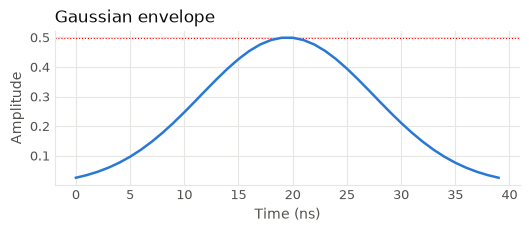

In [25]:
ax = drive_envelope.plot()
ax.set_title("Gaussian envelope", loc="left")
ax.axhline(drive_envelope.peak_amplitude(), color="red", linestyle=":", linewidth=0.8)
plt.show()

To arrange several waveform plots in one figure, create the subplots with Matplotlib and pass each axes object through `target=`. The example below displays six waveforms side by side. For `Arbitrary`, supply the sample values directly as a list.

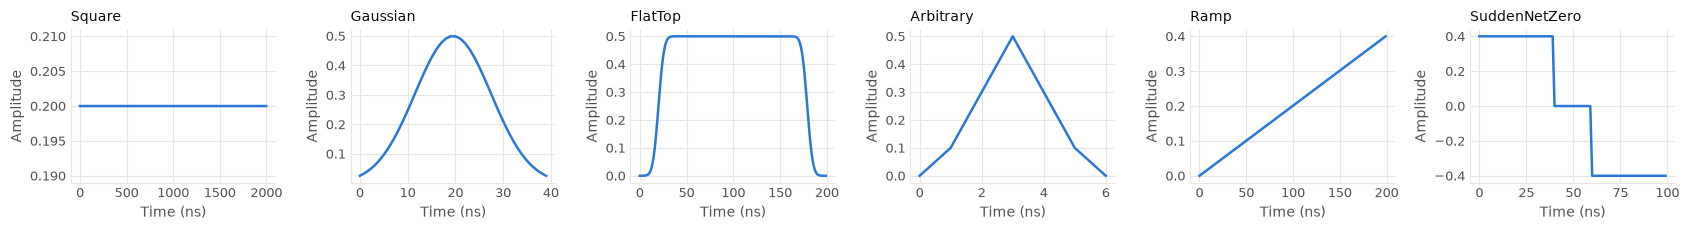

In [26]:
fig, panels = plt.subplots(1, 6, figsize=(17, 2.4))

# target selects the subplot; plot() adds the waveform's title and axis labels.
Square(amplitude=0.2, duration=2000).plot(target=panels[0])

Gaussian(amplitude=0.5, duration=40, sigma=8).plot(target=panels[1])

FlatTop(amplitude=0.5, duration=200, smooth_duration=20).plot(target=panels[2])

# Explicit sample values define an Arbitrary waveform.
Arbitrary([0.0, 0.1, 0.3, 0.5, 0.3, 0.1, 0.0]).plot(target=panels[3])

Ramp(from_amplitude=0.0, to_amplitude=0.4, duration=200).plot(target=panels[4])

SuddenNetZero(amplitude=0.4, duration=100, b=1.0, t_phi=20).plot(target=panels[5])

fig.tight_layout()
plt.show()

Plotting an IQ waveform returns two axes, one for I and one for Q. To draw into existing subplots, pass a pair of axes through `target=`.

The two components use separate vertical scales so that a small quadrature component remains visible. For `pi_pulse`, the peak magnitudes are approximately 0.6192 for I and 0.0056 for Q. The Q component is the DRAG correction, whose scale is controlled by `beta`.

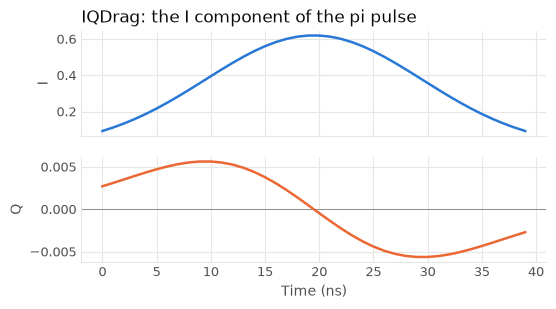

peak I: 0.6192254841732402
peak |Q|: 0.005626876904405126
readout peak Q: 0.0


In [27]:
ax_i, ax_q = pi_pulse.plot()
ax_i.set_title("IQDrag: the I component of the pi pulse", loc="left")
ax_q.axhline(0.0, color="grey", linewidth=0.6)
plt.show()

in_phase = pi_pulse.get_I()
quadrature = pi_pulse.get_Q()

print("peak I:", in_phase.peak_amplitude())
print("peak |Q|:", quadrature.peak_amplitude())  # The smaller DRAG correction.
print("readout peak Q:", readout_pulse.get_Q().peak_amplitude())  # IQZero supplies a zero Q component.

## 1.6 Saving and loading programs

Use `qp.dumps` and `qp.loads` to convert between a program and `.qp` text. Use `qp.save` and `qp.load` to write and read files.

Waveform samples are stored in full. For example, an `Arbitrary` waveform containing 4000 samples stores all 4000 values in the text, without compression or an external array file. If a value or operation cannot be represented, `qp.dumps` raises `qp.SerializationError`.

To check that a program was preserved after saving and loading, compare its body with the original: `loaded_body == qprogram.body`. `QProgram` itself does not define structural equality, so comparing the two program objects directly does not perform this check.

There are two details to consider when saving. A schema loads as a plain `BusSchema` with the same bus definitions, rather than its original typed form. Also, symbolic expressions inside waveform constructors are not supported for a complete save-and-load cycle; resolve them to numeric values before saving.

In [28]:
out = Path("out")
out.mkdir(exist_ok=True)
path = out / "prepare_and_read.qp"

qprogram = qp.loads(prepare_and_read_text)
qp.save(qprogram, path)
loaded_body = qp.load(path).body

print("saved file:", path)
# Compare the bodies, since QProgram itself does not define structural equality.
print("same body structure:", loaded_body == qprogram.body)

saved file: out/prepare_and_read.qp
same body structure: True


Saving the `.qp` file alongside your results preserves the program structure and measurement names without requiring the notebook that created it. Because the format is text, you can compare saved programs to identify changes to operations or waveform parameters.

## 1.7 Running a program

`qp.simulate(qprogram, model=...)` executes a program on QProgram's Python reference platform. The platform interprets the program's structure, including loops and measurements. It does not simulate pulse dynamics or hardware timing, so adding a `wait` does not change the generated measurement values.

A measurement model supplies a sample for each shot. `qp.MockMeasurementModel` provides a configurable model with the following arguments:

- `response`: a function returning the noiseless complex measurement value.
- `noise`: the standard deviation of the Gaussian noise added to each quadrature.
- `raw_samples`: the number of samples in the simulated ADC trace.
- `seed`: a random seed for reproducible results.

The example below contains one measurement without loops or averaging, so it produces one measurement record. `MEAN_IQ` sets the assumed noiseless response to I = 0.62 and Q = 0.18. The response is fixed and does not depend on the pulse sequence. **Basics** shows how the response can depend on a swept variable.

Use `result.get(handle, field=...)` to retrieve an output as an `xarray.DataArray`. This array has named dimensions and coordinates. The integrated result has an `IQ` dimension of length two, with coordinates `"I"` and `"Q"`. Select a quadrature by name with `.sel(IQ="I")` or `.sel(IQ="Q")`.

In [29]:
qprogram = qp.QProgram(label="one_measurement", schema=schema)
qprogram.set_frequency(q[0].readout, 7.20e9)
m_single = qprogram.measure(
    q[0].readout,
    readout_pulse,
    weights,
    fields=(MeasurementField.IQ, MeasurementField.STATE, MeasurementField.RAW),
)

MEAN_IQ = 0.62 + 0.18j  # Assumed noiseless readout response: I=0.62, Q=0.18.

model = qp.MockMeasurementModel(
    response=lambda bus, env: MEAN_IQ,  # The callback returns the same response for every sample.
    noise=0.02,  # Gaussian noise added to each quadrature.
    raw_samples=64,  # Number of samples in the raw trace.
    seed=4,  # Reproduce the same random noise when the cell is rerun.
)
result = qp.simulate(qprogram, model=model)

In [30]:
# Inspect the DataArray directly to see its values, dimensions, and coordinates.
point = result.get(m_single, field=MeasurementField.IQ)
print(point)

# Select each quadrature by name. item() extracts its single numeric value.
print("I:", point.sel(IQ="I").item())
print("Q:", point.sel(IQ="Q").item())

state = result.get(m_single, field=MeasurementField.STATE)
print("classified state:", state.item())

trace = result.get(m_single, field=MeasurementField.RAW)
print("raw trace shape:", trace.shape)  # 64 samples, with I and Q for each sample.

<xarray.DataArray (IQ: 2)> Size: 16B
array([0.60696418, 0.17650565])
Coordinates:
  * IQ       (IQ) <U1 8B 'I' 'Q'
I: 0.6069641769477662
Q: 0.17650565415348446
classified state: 0.0
raw trace shape: (64, 2)


The raw trace contains a sequence of time samples, which can be displayed as a line plot. `result.plot` chooses a plot based on the result's dimensions. **Basics** uses the same method to display results with sweep dimensions, including heatmaps.

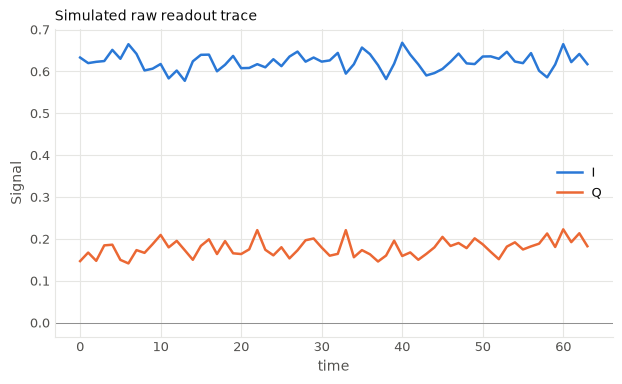

In [31]:
ax_raw = result.plot(
    m_single, field=MeasurementField.RAW, title="Simulated raw readout trace"
)
ax_raw.axhline(0.0, color="grey", linewidth=0.6)
plt.show()

The integrated result contains just one I/Q point, without a time or sweep dimension for `result.plot` to use. Attempting to plot it with this method raises a validation error, shown below. **Basics** introduces repeated measurements and sweeps, which produce arrays of results.

In [32]:
try:
    result.plot(m_single, field=MeasurementField.IQ)
except qp.ValidationError as exc:
    print(exc)

Nothing to plot: an array with dims ('IQ',) is a single measured point with no dimension to plot it against. Sweep a variable, or plot the raw trace, which carries a 'time' dimension.


### 🧩 Exercise 1.1

Define a schema for a flux-tunable transmon, then create a program that sets a flux offset, plays a drive pulse, and performs a readout. Save and load the program, then try an invalid operation to see how schema validation works. Reuse `pi_pulse`, `readout_pulse`, and `weights` from the earlier examples.

1. Create a new flux-tunable transmon schema using `BusSchema.flux_tunable_transmon()`. Assign it to `schema` and use `q = schema.q` to access its qubit buses.
2. Create a `QProgram` with the label `exercise-1.1` and your new schema.
3. Set the offset of `q[0].flux` to `0.05`. Set the drive frequency to `4.85e9` Hz and the readout frequency to `7.20e9` Hz.
4. Play `pi_pulse` on `q[0].drive`, then wait for 400 ns on the same bus.
5. Synchronise the drive and readout buses. Measure `q[0].readout` using `readout_pulse` and `weights`, requesting both `MeasurementField.IQ` and `MeasurementField.STATE`. Store the returned handle.
6. Print the `.qp` text, save the program to `out/exercise_1_1.qp`, and load it back. Compare the original and loaded program bodies.
7. Try to measure `q[0].flux`. Catch `qp.ValidationError` with a `try`/`except` block and print the message.

The schema declares that the flux bus does not support acquisition, so QProgram rejects the measurement when you add it.

Uncomment the hints below and replace each `...` with the missing code. Some gaps need several operations.

In [ ]:
# schema = ...
# q = ...
#
# qprogram = qp.QProgram(label="exercise-1.1", schema=...)
# ...
# qprogram.wait(q[0].drive, 400)
# ...
# m_exercise = qprogram.measure(...)
#
# ...
# exercise_path = out / "exercise_1_1.qp"
# qp.save(qprogram, exercise_path)
# loaded_body = ...
# ...
#
# try:
#     ...
# except qp.ValidationError as exc:
#     print(exc)

## Recap

- Create a `qp.QProgram` and call its methods to add operations. Inspect the resulting structure with `qp.dumps`, `qprogram.buses`, or `body.elements`.
- Identify buses with strings or use `BusSchema` references to validate waveform compatibility, acquisition support, and schema ownership.
- Use `play`, `measure`, and `wait` to add timed operations. Use `sync` to coordinate the timelines of different buses.
- Create waveforms independently, inspect their properties, and plot them. Use string aliases and `with_waveforms` to supply waveform definitions later.
- Save and load programs in the `.qp` format. Compare their bodies to check structural equality.
- Execute examples with `qp.simulate` and a measurement model. Retrieve requested fields using measurement handles, and plot results that have a time or sweep dimension.

## Next

In **Basics**, you will use variables to parameterise operations, sweeps to vary their values, and `average(shots)` to repeat measurements. You will then inspect and plot the resulting arrays using their named dimensions and coordinates.